<a href="https://colab.research.google.com/github/AryaPutra-i/Pengolahan_citra_3012310006_arya-putra-irwansyah/blob/main/Pertemuan_2_pengolahan_citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Tinggi asli: 397, Lebar asli: 352
tipe data: <class 'numpy.ndarray'>
shape    : (397, 352, 3)
dtype   : uint8

artinya: 
Tinggi = 397 piksel
lebar = 352 piksel
channel = 3 piksel
total pixel:  139744


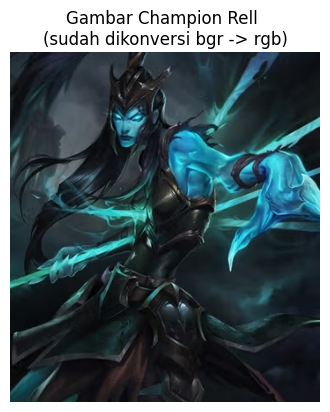

In [36]:
# Baca gambar dari file
#cv2.imread() mengembalikan array numpy !
img_bgr = cv2.imread('kalista_2.jpg')

#resize agar tidak terlalu besar
h, w, c = img_bgr.shape
print(f"Tinggi asli: {h}, Lebar asli: {w}")
img_bgr = cv2.resize(img_bgr, (w, h), fx=0.5, fy=0.5)

#cek tipe data : ternyata sudah array numpy!
print("tipe data:", type(img_bgr))
print("shape    :", img_bgr.shape)
print("dtype   :", img_bgr.dtype)

print()
print("artinya: ")
print(f"Tinggi = {img_bgr.shape[0]} piksel")
print(f"lebar = {img_bgr.shape[1]} piksel")
print(f"channel = {img_bgr.shape[2]} piksel")

#konversi bgr -> rgb untuk ditampilkan di matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("total pixel: ", img_rgb.shape[0] * img_rgb.shape[1])

plt.figure(figsize=(4,6))
plt.imshow(img_rgb)
plt.title('Gambar Champion Rell \n(sudah dikonversi bgr -> rgb)')
plt.axis('off')
plt.show()

=== matriks f(x,y) - area 8x8 piksel ===
setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)

[[14 14 15 18 19 21 19 17]
 [13 15 17 18 18 18 18 19]
 [12 16 18 19 18 16 16 19]
 [13 16 20 18 18 16 18 20]
 [14 16 18 18 17 17 17 19]
 [17 17 17 17 18 17 17 18]
 [19 17 16 17 18 18 17 16]
 [19 17 17 18 18 18 16 14]]

CONTOH baca: f(180, 200) = 14
CONTOH baca: f(181, 201) = 15
CONTOH baca: f(181, 201) = [14 15 19]


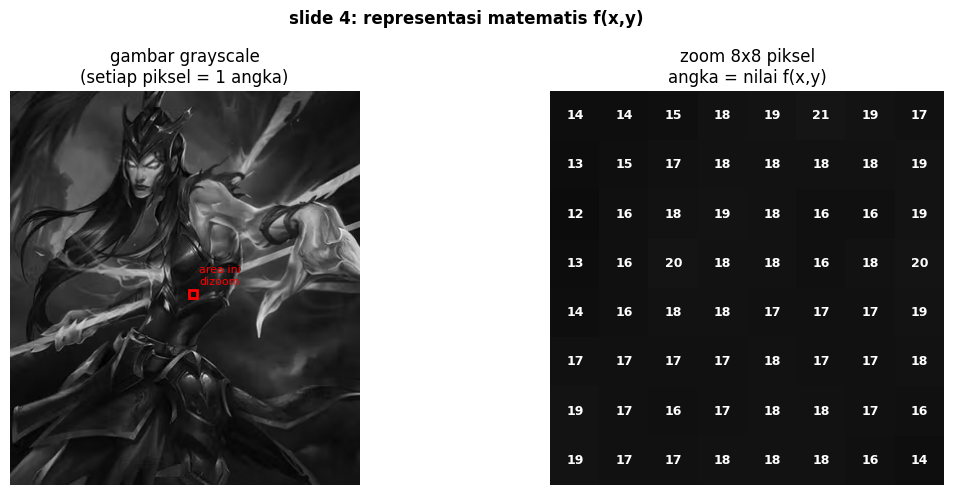

In [37]:
import matplotlib.patches as patches

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

#Ambil area kecil
area_kecil = img_gray[200:208, 180:188]

print("=== matriks f(x,y) - area 8x8 piksel ===")
print("setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)")
print()
print(area_kecil)
print()
print("CONTOH baca:" , f"f(180, 200) = {img_gray[200,180]}")
print("CONTOH baca:" , f"f(181, 201) = {img_gray[201,181]}")
print("CONTOH baca:" , f"f(181, 201) = {img_rgb[201,181]}")


fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('gambar grayscale\n(setiap piksel = 1 angka)')
axes[0].axis('off')
rect=patches.Rectangle((180,200),8 ,8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(190, 195, 'area ini\ndizoom', color='red', fontsize=8)

axes[1].imshow(area_kecil, cmap='gray', vmin=0, vmax=255)
for i in range(8):
  for j in range(8):
    nilai = area_kecil[i,j]
    warna_teks = 'white' if nilai < 128 else 'black'
    axes[1].text(j, i, str(nilai), ha='center', va='center',
                 fontsize=9, color=warna_teks, fontweight='bold')
axes[1].set_title('zoom 8x8 piksel\nangka = nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()

=== matriks f(x,y) - area 8x8 piksel ===

Row 0: [46, 50, 59], [45, 48, 57], [42, 42, 52], [66, 66, 76], [101, 99, 110], [52, 51, 59], [66, 66, 74], [41, 44, 51]
Row 1: [44, 48, 57], [39, 42, 51], [37, 37, 47], [73, 73, 83], [89, 87, 98], [52, 52, 62], [74, 74, 82], [37, 40, 47]
Row 2: [42, 46, 55], [30, 33, 42], [32, 32, 42], [80, 80, 90], [71, 69, 80], [55, 55, 65], [64, 64, 72], [35, 38, 45]
Row 3: [42, 45, 54], [27, 30, 39], [32, 32, 42], [85, 85, 95], [58, 56, 67], [55, 55, 65], [50, 53, 60], [34, 37, 44]
Row 4: [40, 43, 52], [27, 27, 37], [33, 33, 41], [76, 76, 84], [49, 49, 59], [51, 51, 61], [52, 55, 64], [35, 39, 48]
Row 5: [39, 39, 49], [24, 24, 34], [34, 34, 42], [68, 68, 76], [47, 47, 57], [46, 46, 56], [50, 53, 62], [37, 41, 50]
Row 6: [34, 34, 42], [23, 23, 31], [33, 33, 41], [62, 62, 70], [46, 46, 56], [44, 44, 54], [48, 50, 62], [38, 42, 53]
Row 7: [29, 29, 37], [22, 22, 30], [33, 33, 41], [55, 55, 63], [47, 47, 57], [43, 43, 53], [46, 48, 60], [39, 43, 54]

CONTOH baca

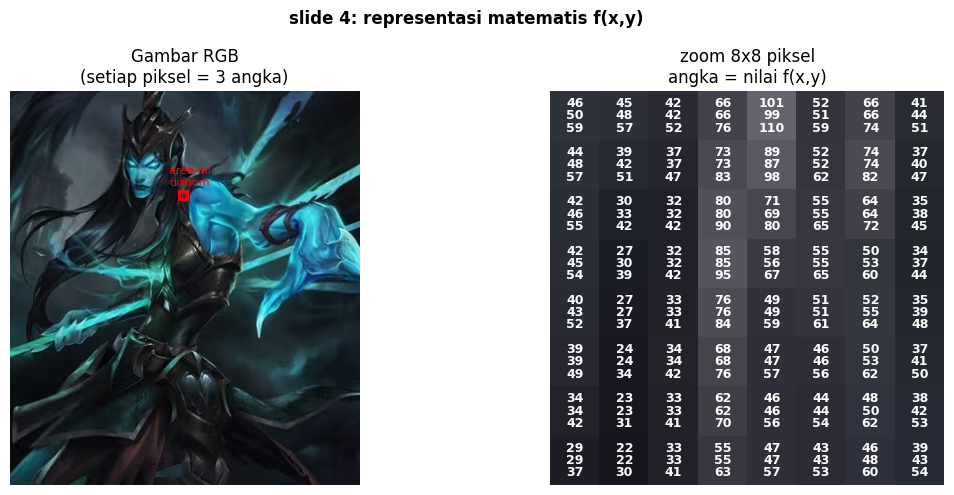

In [48]:
import matplotlib.patches as patches

#Ambil area kecil
area_kecil_rgb = img_rgb[100:108, 170:178]

print("=== matriks f(x,y) - area 8x8 piksel ===")
print()

for row_index, row in enumerate(area_kecil_rgb):
    row_str = []
    for pixel in row:
        row_str.append(f"[{pixel[0]}, {pixel[1]}, {pixel[2]}]")
    print(f"Row {row_index}: {', '.join(row_str)}")

print()
print("CONTOH baca:" , f"f(210, 190) = {img_rgb[210,190]}")
print("CONTOH baca:" , f"f(211, 191) = {img_rgb[211,191]}")

total_pixel = img_rgb.shape[0] * img_rgb.shape[1]
konversi_kb = (total_pixel*3)/1024
konversi_mb = konversi_kb/1024

print("total pixel: ", total_pixel)
print("total Size Kb: ", round(konversi_kb))
print("total Size MB: ", round(konversi_mb, 2))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img_rgb, vmin=0, vmax=255)
axes[0].set_title('Gambar RGB\n(setiap piksel = 3 angka)')
axes[0].axis('off')
rect=patches.Rectangle((170,100),8 ,8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(160, 95, 'area ini\ndizoom', color='red', fontsize=8)

def tentukan_warna(skor):
  match skor:
      case r if r < 125:
        return 'white'
      case _:
        return 'black'

axes[1].imshow(area_kecil_rgb)
for i in range(8):
  for j in range(8):
    nilai_rgb = area_kecil_rgb[i,j]
    offsets = [-0.25, 0 ,0.25]
    for mn in range(3):
      nilai_rgb_satuan = nilai_rgb[mn]
      hasil_cek = tentukan_warna(nilai_rgb_satuan)
      axes[1].text(j, i + offsets[mn], str(nilai_rgb_satuan), ha='center', va='center',fontsize=9, color=hasil_cek, fontweight='bold')

axes[1].set_title('zoom 8x8 piksel\nangka = nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()